In [67]:
import json
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 원본 파일 확보

* 저장한 텍스트 파일을 가공

In [21]:
all_items = []
with open('visit_jeju_c1_raw.txt', 'r', encoding='utf-8') as infile:
    for line in infile:
        line = line.strip()
        data = json.loads(line)['items'] #사용할 items 키만 가져오기
        all_items.extend(data)
    print(type(all_items))

<class 'list'>


In [22]:
# 데이터 프레임으로 변환
# df = pd.DataFrame(all_items)

* csv파일 저장(원본)
     * totalCount: 1341와 csv데이터 개수 동일함을 확인.

In [23]:
# df.to_csv('visit_jeju_c1_raw.csv',index=False, encoding='utf-8') --- <저장 완료>

# 데이터 전처리

# 1. csv파일 평탄화
    * 칼럼 중 하위 딕셔너리가 있는 칼럼이 있음
    * 따라서 평탄화 함수를 사용함 (json_normalize : 중첩된 JSON 데이터를 평탄화하여 DataFrame으로 변환하는 함수)
    * 이 중 사용할 칼럼만 추출하기 ('contentscd' 필요 없음 'region1cd', 'region2cd'는 value, label 남기기, 'repPhoto'는 전체 남기기)

In [24]:
df = pd.json_normalize(all_items, sep="_")
# print(df)
# df.to_csv('visit_jeju_c1_normalized.csv',index=False, encoding='utf-8') ---<저장 완료>

In [25]:
# 칼럼명 공백 제거
columns = df.columns
print(columns)
df.columns = df.columns.str.strip()

Index(['alltag', 'contentsid', 'title', 'address', 'roadaddress', 'tag',
       'introduction', 'latitude', 'longitude', 'postcode', 'phoneno',
       'contentscd_value', 'contentscd_label', 'contentscd_refId',
       'region1cd_value', 'region1cd_label', 'region1cd_refId',
       'region2cd_value', 'region2cd_label', 'region2cd_refId',
       'repPhoto_descseo', 'repPhoto_photoid_photoid',
       'repPhoto_photoid_imgpath', 'repPhoto_photoid_thumbnailpath'],
      dtype='object')


# 2. 데이터 정제
    * 결측치, 이상치 정리

In [26]:
df.shape

(1341, 24)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   alltag                          1341 non-null   object 
 1   contentsid                      1341 non-null   object 
 2   title                           1341 non-null   object 
 3   address                         1336 non-null   object 
 4   roadaddress                     1331 non-null   object 
 5   tag                             1341 non-null   object 
 6   introduction                    1341 non-null   object 
 7   latitude                        1324 non-null   float64
 8   longitude                       1324 non-null   float64
 9   postcode                        354 non-null    object 
 10  phoneno                         1188 non-null   object 
 11  contentscd_value                1341 non-null   object 
 12  contentscd_label                13

* 전체 결측치가 있는 칼럼 조회

In [28]:
missing_columns = df.isnull().any()
print(missing_columns)

alltag                            False
contentsid                        False
title                             False
address                            True
roadaddress                        True
tag                               False
introduction                      False
latitude                           True
longitude                          True
postcode                           True
phoneno                            True
contentscd_value                  False
contentscd_label                  False
contentscd_refId                  False
region1cd_value                   False
region1cd_label                   False
region1cd_refId                   False
region2cd_value                   False
region2cd_label                   False
region2cd_refId                   False
repPhoto_descseo                  False
repPhoto_photoid_photoid          False
repPhoto_photoid_imgpath          False
repPhoto_photoid_thumbnailpath     True
dtype: bool


* 결측치 존재하는 칼럼만 필터링

In [29]:
column_missing_values = missing_columns [ missing_columns == True ]
print(column_missing_values)

address                           True
roadaddress                       True
latitude                          True
longitude                         True
postcode                          True
phoneno                           True
repPhoto_photoid_thumbnailpath    True
dtype: bool


* 'alltag','tag' 칼럼 병합

In [30]:
alltag = df['alltag'].str.split(',')
tag    = df['tag'].str.split(',')      
df['merged_tag'] = [list(dict.fromkeys(a + b)) for a, b in zip(alltag, tag)]
#리스트 데이터 순서 유지를 위해 dict.fromkeys 사용 후 리스트로 타입 다시 변경

In [31]:
df[['tag','alltag','merged_tag']]

,tag,alltag,merged_tag
0,"예술,실내,미술/박물관,흐림,사계절,실내관광지,어트랙션","예술,실내,미술/박물관,흐림,사계절,실내관광지,어트랙션,공용주차장,아주 어려움","[예술, 실내, 미술/박물관, 흐림, 사계절, 실내관광지, 어트랙션, 공용주차장, ..."
1,"반려견유치원,반려견호텔,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험","반려견유치원,반려견호텔,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험,공...","[반려견유치원, 반려견호텔, 반려동물, 반려동물동반입장, 혼저옵서개, 반려동물동반_..."
2,"해양스포츠, 스쿠버다이빙, 체험다이빙, 야간다이빙, 자격증코스, 펀다이빙","해양스포츠, 스쿠버다이빙, 체험다이빙, 야간다이빙, 자격증코스, 펀다이빙,공용주차장...","[해양스포츠, 스쿠버다이빙, 체험다이빙, 야간다이빙, 자격증코스, 펀다이빙..."
3,"제주, 서귀포, 갤러리, 미술관, 작은미술관, 그림공방, 작품감상, 작품구매, 초상...","제주, 서귀포, 갤러리, 미술관, 작은미술관, 그림공방, 작품감상, 작품구매, 초상...","[제주, 서귀포, 갤러리, 미술관, 작은미술관, 그림공방, 작품감상, ..."
4,"포구,해변,문화유적지,자연경관,역사유적","포구,해변,문화유적지","[포구, 해변, 문화유적지, 자연경관, 역사유적]"
...,...,...,...
1336,"제주여행, 제주서귀포가볼만한곳, 제주도문화, 민속촌, 야간개장, 제주핫플, 제주동쪽...","제주여행, 제주서귀포가볼만한곳, 제주도문화, 민속촌, 야간개장, 제주핫플, 제주동쪽...","[제주여행, 제주서귀포가볼만한곳, 제주도문화, 민속촌, 야간개장, 제주핫플..."
1337,"해변,여자,남자,맑음,언택트","해변,여자,남자,맑음","[해변, 여자, 남자, 맑음, 언택트]"
1338,"제주동쪽가볼만한곳, 제주오름, 제주핫플, 제주억새, 산책로, 오름추천, 제주동쪽, ...","제주동쪽가볼만한곳, 제주오름, 제주핫플, 제주억새, 산책로, 오름추천, 제주동쪽, ...","[제주동쪽가볼만한곳, 제주오름, 제주핫플, 제주억새, 산책로, 오름추천, ..."
1339,"반려동물수제간식,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험","반려동물수제간식,반려동물,반려동물동반입장,혼저옵서개,반려동물동반_기타체험,유도 및 ...","[반려동물수제간식, 반려동물, 반려동물동반입장, 혼저옵서개, 반려동물동반_기타체험,..."


* 'address', 'roadaddress' 칼럼 전처리           
    * 이상치 삭제 : [object Object], '-', 둘다 '제주특별자치도'만 값으로 있는 경우
    * 결측치 수정 : 'address'에 데이터 삽입          
    * roadaddress로 두 주소열 데이터 통합           

In [44]:
#이상치 삭제
df[['address', 'roadaddress']]= df[['address', 'roadaddress']].replace(['-', '제주특별자치도', '[object Object]'],'',)
df[['address', 'roadaddress']]

,address,roadaddress
0,제주특별자치도 서귀포시 대정읍 무릉리 3296,제주특별자치도 서귀포시 대정읍 서삼중로 117
1,제주특별자치도 서귀포시 대정읍 신도리 7,제주특별자치도 서귀포시 대정읍 칠전로 438
2,제주특별자치도 서귀포시 남원읍 하례리 343-1 1,제주특별자치도 서귀포시 남원읍 일주동로 8034 (하례리) 1
3,제주특별자치도 서귀포시 신효동 768-3 1층,제주특별자치도 서귀포시 효돈로 114 (신효동) 1층
4,제주특별자치도 제주시 추자면 대서리,제주특별자치도 제주시 추자면 대서리
...,...,...
1336,제주특별자치도 서귀포시 표선면 표선리 40-1,제주특별자치도 서귀포시 표선면 민속해안로 631-34
1337,제주특별자치도 서귀포시 남원읍 위미리 1757-12,제주특별자치도 서귀포시 남원읍 위미중앙로196번길 6-13
1338,제주특별자치도 서귀포시 표선면 성읍리 산 1,제주특별자치도 서귀포시 표선면 성읍리 산 1
1339,제주특별자치도 제주시 노형동 722-2,제주특별자치도 제주시 연북로 41


* 엑셀 필터링 시, 'address', 'roadaddress' 두 칼럼 모두 결측치가 존재하는 경우 -- 총 6건    
* 6건 중 위경도 좌표 값이 존재 하는 경우 3건 수정
    * https://gps.aply.biz/ 위경도 좌표 <-> 주소 변환 사이트
    

* 나머지 3건(위경도 좌표 값도 존재하지 않는 경우) 주소 검색 후 삽입

In [45]:
# df.to_csv('visit_jeju_c1_cleaned.csv',index=False, encoding='utf-8') -- 중간 참고용

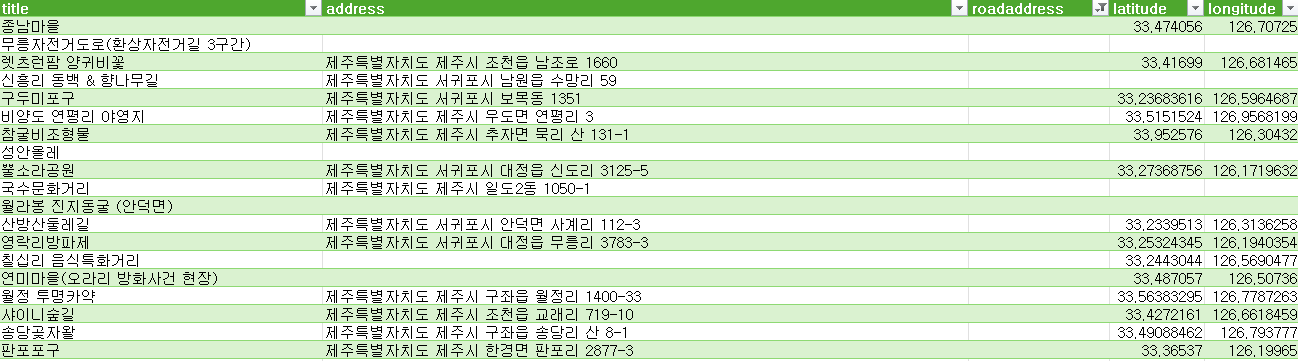

In [53]:
#주소 삽입
df.loc[75, 'address']  = '제주특별자치도 제주시 조천읍 선흘리 1780'   #종남마을
df.loc[91, 'address']  = '제주특별자치도 제주시 한경면 판포리 1610'   #무릉자전거도로(환상자전거길 3구간)
df.loc[448, 'address']  = '제주특별자치도 제주시 사라봉동길 74'       #성안올레
df.loc[515, 'address']  = '제주특별자치도 서귀포시 안덕면 감산리 1144' #월라봉 진지동굴 (안덕면)
df.loc[565, 'address']  = '제주특별자치도 서귀포시 서귀동 70'         #칠십리 음식특화거리
df.loc[576, 'address']  = '제주특별자치도 제주시 오라이동 1948-2'     #연미마을(오라리 방화사건 현장)

In [54]:
df.loc[[75, 91, 448, 515, 565, 576], ['title', 'address']]

,title,address
75,종남마을,제주특별자치도 제주시 조천읍 선흘리 1780
91,무릉자전거도로(환상자전거길 3구간),제주특별자치도 제주시 한경면 판포리 1610
448,성안올레,제주특별자치도 제주시 사라봉동길 74
515,월라봉 진지동굴 (안덕면),제주특별자치도 서귀포시 안덕면 감산리 1144
565,칠십리 음식특화거리,제주특별자치도 서귀포시 서귀동 70
576,연미마을(오라리 방화사건 현장),제주특별자치도 제주시 오라이동 1948-2


* 'roadaddress' 결측치를 'address' 값으로 채우기

In [68]:
df['roadaddress'].replace('', np.nan, inplace=True)
df['roadaddress'] = df['roadaddress'].fillna(df['address'])

In [69]:
df.loc[[75, 91, 448, 515, 565, 576], ['title', 'roadaddress']]

,title,roadaddress
75,종남마을,제주특별자치도 제주시 조천읍 선흘리 1780
91,무릉자전거도로(환상자전거길 3구간),제주특별자치도 제주시 한경면 판포리 1610
448,성안올레,제주특별자치도 제주시 사라봉동길 74
515,월라봉 진지동굴 (안덕면),제주특별자치도 서귀포시 안덕면 감산리 1144
565,칠십리 음식특화거리,제주특별자치도 서귀포시 서귀동 70
576,연미마을(오라리 방화사건 현장),제주특별자치도 제주시 오라이동 1948-2


In [70]:
df.info()
# roadaddress 결측치 없음을 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   alltag                          1341 non-null   object 
 1   contentsid                      1341 non-null   object 
 2   title                           1341 non-null   object 
 3   address                         1340 non-null   object 
 4   roadaddress                     1341 non-null   object 
 5   tag                             1341 non-null   object 
 6   introduction                    1341 non-null   object 
 7   latitude                        1324 non-null   float64
 8   longitude                       1324 non-null   float64
 9   postcode                        354 non-null    object 
 10  phoneno                         1188 non-null   object 
 11  contentscd_value                1341 non-null   object 
 12  contentscd_label                13

In [72]:
# df.to_csv('visit_jeju_c1_cleaned.csv',index=False, encoding='utf-8') #-- 중간 참고용

* 'latitude', 'longitude' 칼럼 전처리

In [ ]:
# 'latitude', 'longitude'가 0인 값은 Nan값으로 대체

In [76]:
df[['latitude', 'longitude']] = df[['latitude', 'longitude']].replace(0, np.nan)

In [77]:
# 'latitude' 또는 'longitude'가 NaN인 행 필터링
missing_coords = df[df['latitude'].isna() | df['longitude'].isna()]
missing_coords[['title', 'address', 'roadaddress', 'latitude', 'longitude']]

,title,address,roadaddress,latitude,longitude
3,그림휴가,제주특별자치도 서귀포시 신효동 768-3 1층,제주특별자치도 서귀포시 효돈로 114 (신효동) 1층,NaN,NaN
45,중앙로,제주특별자치도 제주시 중앙로,제주특별자치도 제주시 중앙로,NaN,NaN
71,병악현무암지대,제주특별자치도 서귀포시 안덕면 사계리,제주특별자치도 서귀포시 안덕면 사계리,NaN,NaN
91,무릉자전거도로(환상자전거길 3구간),제주특별자치도 제주시 한경면 판포리 1610,제주특별자치도 제주시 한경면 판포리 1610,NaN,NaN
170,종달고망난돌쉼터,제주 제주시 구좌읍 종달리 112-4,제주 제주시 구좌읍 종달리 112-4,NaN,NaN
213,신흥리 동백 & 향나무길,제주특별자치도 서귀포시 남원읍 수망리 59,제주특별자치도 서귀포시 남원읍 수망리 59,NaN,NaN
286,오투힐 제주점,제주특별자치도 제주시 봉개동 700-5 2층 오투힐 제주점,제주특별자치도 제주시 명림로 100 (봉개동) 2층 오투힐 제주점,NaN,NaN
331,신산신양해안도로 (해산물),제주특별자치도 서귀포시 성산읍 고성리,제주특별자치도 서귀포시 성산읍 고성리,NaN,NaN
427,한담컬쳐,제주특별자치도 제주시 애월읍 애월리 2493-1,제주특별자치도 제주시 애월읍 애월로1길 18 (애월리),NaN,NaN
448,성안올레,제주특별자치도 제주시 사라봉동길 74,제주특별자치도 제주시 사라봉동길 74,NaN,NaN


* 'latitude', 'longitude' 값 삽입
   * https://gps.aply.biz/ 위경도 좌표 <-> 주소 변환 사이트

In [78]:
df.loc[3,   ['latitude','longitude']]   = [33.26362157054069, 126.61110844041804]   # 그림휴가 
df.loc[45,  ['latitude','longitude']]   = [33.518154271, 126.525126215]   # 중앙로
df.loc[71,  ['latitude','longitude']]   = [33.24668494568891, 126.32100940722538]   # 병악현무암지대
df.loc[91,  ['latitude','longitude']]   = [33.369968353966726, 126.20649255335972]   # 무릉자전거도로(환상자전거길 3구간)
df.loc[170, ['latitude','longitude']]   = [33.50992996378095, 126.90735711256157]   # 종달고망난돌쉼터
df.loc[213, ['latitude','longitude']]   = [33.32996840405765, 126.73214372762041]   # 신흥리 동백 & 향나무길
df.loc[286, ['latitude','longitude']]   = [33.477401223405614, 126.60725221645978]   # 오투힐 제주점
df.loc[331, ['latitude','longitude']]   = [33.432071427409646, 126.93192072712114]   # 신산신양해안도로 (해산물)
df.loc[427, ['latitude','longitude']]   = [33.46256316156877, 126.31062094828056]   # 한담컬쳐
df.loc[448, ['latitude','longitude']]   = [33.518662113, 126.547691497]   # 성안올레
df.loc[465, ['latitude','longitude']]   = [33.51014040669438, 126.53244860605903]   # 국수문화거리
df.loc[504, ['latitude','longitude']]   = [33.321328872193945, 126.20036161615099]   # 쏙인제주
df.loc[515, ['latitude','longitude']]   = [33.24398323800529, 126.34957211436719]   # 월라봉 진지동굴 (안덕면)	
df.loc[529, ['latitude','longitude']]   = [33.462325598661835, 126.310482182323]   # 제주 카약올레
df.loc[532, ['latitude','longitude']]   = [33.210630427115, 126.25735613143948]   # 케이제주해양사업단
df.loc[920, ['latitude','longitude']]   = [33.4335399179775, 126.42167599813081]   # 아이바가든
df.loc[921, ['latitude','longitude']]   = [33.4335399179775, 126.42167599813081]   # 김정문알로에 알로에숲
df.loc[1262,['latitude','longitude']]   = [33.445209947, 126.294445524]   # 영등할망 신화공원
df.loc[1302,['latitude','longitude']]   = [33.26175884924661, 126.56713341145925]   # 제주친구

In [79]:
#삽입 결과 확인
df.loc[[3, 45, 71, 91, 170,213, 286, 331, 427, 448, 465, 504, 515, 529, 532,920, 921, 1262, 1302], ['latitude','longitude']]

,latitude,longitude
3,33.263622,126.611108
45,33.518154,126.525126
71,33.246685,126.321009
91,33.369968,126.206493
170,33.509930,126.907357
213,33.329968,126.732144
286,33.477401,126.607252
331,33.432071,126.931921
427,33.462563,126.310621
448,33.518662,126.547691


* 'postcode' -> 미사용, 'phoneno' -> 값 있는 경우만 보여줄 예정. 사용하는 열

* repPhoto_photoid_thumbnailpath ->  썸네일 이미지경로 없지만 사용하는 열

In [81]:
# df.to_csv('visit_jeju_c1_cleaned.csv',index=False, encoding='utf-8') #-- 중간 참고용

In [80]:
df.columns

Index(['alltag', 'contentsid', 'title', 'address', 'roadaddress', 'tag',
       'introduction', 'latitude', 'longitude', 'postcode', 'phoneno',
       'contentscd_value', 'contentscd_label', 'contentscd_refId',
       'region1cd_value', 'region1cd_label', 'region1cd_refId',
       'region2cd_value', 'region2cd_label', 'region2cd_refId',
       'repPhoto_descseo', 'repPhoto_photoid_photoid',
       'repPhoto_photoid_imgpath', 'repPhoto_photoid_thumbnailpath',
       'merged_tag'],
      dtype='object')

In [82]:
#쓸 칼럼만 남기기
cleaned_df = df[['contentsid', 'title', 'roadaddress',
       'introduction', 'latitude', 'longitude', 'phoneno',
       'region1cd_value', 'region1cd_label', 'region2cd_value', 'region2cd_label',
       'repPhoto_descseo', 'repPhoto_photoid_photoid',
       'repPhoto_photoid_imgpath', 'repPhoto_photoid_thumbnailpath',
       'merged_tag']]
cleaned_df

,contentsid,title,roadaddress,introduction,latitude,longitude,phoneno,region1cd_value,region1cd_label,region2cd_value,region2cd_label,repPhoto_descseo,repPhoto_photoid_photoid,repPhoto_photoid_imgpath,repPhoto_photoid_thumbnailpath,merged_tag
0,CNTS_000000000019003,제주국제예술센터,제주특별자치도 서귀포시 대정읍 서삼중로 117,제주의 문화와 예술이 담긴 곳,33.271830,126.199440,010-4696-8799,region2,서귀포시,22,대정,제주국제예술센터,4131,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[예술, 실내, 미술/박물관, 흐림, 사계절, 실내관광지, 어트랙션, 공용주차장, ..."
1,CNTS_300000000012728,제주펫스쿨,제주특별자치도 서귀포시 대정읍 칠전로 438,“반려견과 보호자가 함께하는 올바른 반려문화를 만들어요.”\r\n 제주펫스쿨에서는 ...,33.286427,126.223154,0507-1365-4504,region2,서귀포시,22,대정,제주펫스쿨,2019022621770,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[반려견유치원, 반려견호텔, 반려동물, 반려동물동반입장, 혼저옵서개, 반려동물동반_..."
2,CNTS_300000000013522,샤카다이브,제주특별자치도 서귀포시 남원읍 일주동로 8034 (하례리) 1,제주 서귀포시에 위치한 다이빙샵 샤카다이브 입니다,33.325226,126.596193,010-2335-6446,region2,서귀포시,25,남원,샤카다이브,2019022651417,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[해양스포츠, 스쿠버다이빙, 체험다이빙, 야간다이빙, 자격증코스, 펀다이빙..."
3,CNTS_300000000013707,그림휴가,제주특별자치도 서귀포시 효돈로 114 (신효동) 1층,"미술작가 김미형이 서귀포에 문을 연 미술공간이다. 작품 감상 및 구매, 초상화 주문...",33.263622,126.611108,0507-1426-5071,region2,서귀포시,21,서귀포시내,그림휴가,2019022655924,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[제주, 서귀포, 갤러리, 미술관, 작은미술관, 그림공방, 작품감상, ..."
4,CNTS_000000000021026,상추자포구,제주특별자치도 제주시 추자면 대서리,상추자도 추자항에 위치한 포구,33.964290,126.292984,--,region3,섬 속의 섬,32,추차도,상추자포구,2019022560665,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[포구, 해변, 문화유적지, 자연경관, 역사유적]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1336,CONT_000000000500553,제주민속촌,제주특별자치도 서귀포시 표선면 민속해안로 631-34,제주에서 가장 제주다움을 볼 수 있는 곳... ‘제주민속촌’,33.322510,126.841818,0507-1457-4502,region2,서귀포시,26,표선,제주민속촌24,2019022634628,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[제주여행, 제주서귀포가볼만한곳, 제주도문화, 민속촌, 야간개장, 제주핫플..."
1337,CNTS_000000000019194,위미항,제주특별자치도 서귀포시 남원읍 위미중앙로196번길 6-13,제주의 벚꽃이 가장 먼저 피는 따뜻한 곳,33.270709,126.663636,--,region2,서귀포시,25,남원,위미항,4535,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[해변, 여자, 남자, 맑음, 언택트]"
1338,CONT_000000000500232,백약이오름,제주특별자치도 서귀포시 표선면 성읍리 산 1,"하늘로 향하는 길, 백약이오름",33.437283,126.790180,None,region2,서귀포시,26,표선,백약이오름,2019022643097,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[제주동쪽가볼만한곳, 제주오름, 제주핫플, 제주억새, 산책로, 오름추천, ..."
1339,CNTS_300000000012721,쿠킹독,제주특별자치도 제주시 연북로 41,100% 핸드메이드 수제간식을 판매하는 이곳은 반려동물의 알레르기와 건강 등을 고려...,33.482344,126.485860,0507-1335-8763,region1,제주시,11,제주시내,쿠킹독,2019022621673,https://api.cdn.visitjeju.net/photomng/imgpath...,https://api.cdn.visitjeju.net/photomng/thumbna...,"[반려동물수제간식, 반려동물, 반려동물동반입장, 혼저옵서개, 반려동물동반_기타체험,..."


# 3. 데이터 가공 완료

* 최종 csv 파일저장

In [83]:
# cleaned_df.to_csv('visit_jeju_c1_final_cleaned.csv',index=False, encoding='utf-8') # --- <저장완료>

In [85]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   contentsid                      1341 non-null   object 
 1   title                           1341 non-null   object 
 2   roadaddress                     1341 non-null   object 
 3   introduction                    1341 non-null   object 
 4   latitude                        1341 non-null   float64
 5   longitude                       1341 non-null   float64
 6   phoneno                         1188 non-null   object 
 7   region1cd_value                 1341 non-null   object 
 8   region1cd_label                 1341 non-null   object 
 9   region2cd_value                 1341 non-null   object 
 10  region2cd_label                 1341 non-null   object 
 11  repPhoto_descseo                1341 non-null   object 
 12  repPhoto_photoid_photoid        13